In [1]:
# !pip install growwapi
# !pip install --upgrade growwapi
# !pip install pyarrow fastparquet

In [5]:
import pandas as pd
import numpy as np
import math
from itertools import combinations
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from statsmodels.tsa.stattools import coint
from growwapi import GrowwAPI

In [6]:
API_Key = "eyJraWQiOiJaTUtjVXciLCJhbGciOiJFUzI1NiJ9.eyJleHAiOjI1NjIxMjM2ODEsImlhdCI6MTc3MzcyMzY4MSwibmJmIjoxNzczNzIzNjgxLCJzdWIiOiJ7XCJ0b2tlblJlZklkXCI6XCJlNTA5MDE2MC0xMmYxLTQwM2UtOTkwMy1lZTI4NThlNmZhZjBcIixcInZlbmRvckludGVncmF0aW9uS2V5XCI6XCJlMzFmZjIzYjA4NmI0MDZjODg3NGIyZjZkODQ5NTMxM1wiLFwidXNlckFjY291bnRJZFwiOlwiODdlODE1ZjAtZWM5MS00OTU4LWIwNzUtMDg0MWMyMTk2MzNkXCIsXCJkZXZpY2VJZFwiOlwiNTEyN2ZiZjktMTZiMS01NzUzLTk2MjgtOTQyMTQwNGJhZDYwXCIsXCJzZXNzaW9uSWRcIjpcIjkxMGZmMTIwLTA0NmUtNGIwYy1iNTA2LTI4MDRkOTk5ODdmZVwiLFwiYWRkaXRpb25hbERhdGFcIjpcIno1NC9NZzltdjE2WXdmb0gvS0EwYkFvc2NJMXRRNzBlTXdSeHhOa1IxMTlSTkczdTlLa2pWZDNoWjU1ZStNZERhWXBOVi9UOUxIRmtQejFFQisybTdRPT1cIixcInJvbGVcIjpcImF1dGgtdG90cFwiLFwic291cmNlSXBBZGRyZXNzXCI6XCI0OS4yNDguMTAyLjE1OCwxNzIuNjkuODYuMjQsMzUuMjQxLjIzLjEyM1wiLFwidHdvRmFFeHBpcnlUc1wiOjI1NjIxMjM2ODEzOTAsXCJ2ZW5kb3JOYW1lXCI6XCJncm93d0FwaVwifSIsImlzcyI6ImFwZXgtYXV0aC1wcm9kLWFwcCJ9.hHbLKUV6B-HUCEPm1PIvVraZ_04mxU9gY7REhotOEa-TRmdQw-CTaOZJDCg5epie7p9AkRjFDnGg2UEpDDO3Qw"
Secret_Key = "Z5Vuwy5*u-qhmJA!Yuc_jm__Jw8-BLIC"

In [7]:
access_token = GrowwAPI.get_access_token(api_key=API_Key, secret=Secret_Key)
# Use access_token to initiate GrowwAPI
groww = GrowwAPI(access_token)

Ready to Groww!


In [8]:
symbol_segment_map = {'RELIANCE': 'Oil Gas & Consumable Fuels', 'HDFCBANK': 'Financial Services', 
                      'ICICIBANK': 'Financial Services', 'INFY': 'Information Technology', 'TCS': 'Information Technology',
                      'HINDUNILVR': 'FMCG', 'ITC': 'FMCG', 'BHARTIARTL': 'Telecommunication', 'SBIN': 'Financial Services',
                      'KOTAKBANK': 'Financial Services', 'AXISBANK': 'Financial Services', 'BAJFINANCE': 'Financial Services',
                      'BAJAJFINSV': 'Financial Services', 'HCLTECH': 'Information Technology', 
                      'WIPRO': 'Information Technology', 'LTIM': 'Information Technology', 'TECHM': 'Information Technology',
                      'LT': 'Construction', 'ULTRACEMCO': 'Construction Materials', 'GRASIM': 'Construction Materials', 
                      'SHREECEM': 'Construction Materials', 'TATASTEEL': 'Metals & Mining', 'JSWSTEEL': 'Metals & Mining', 
                      'HINDALCO': 'Metals & Mining', 'COALINDIA': 'Oil Gas & Consumable Fuels', 
                      'ONGC': 'Oil Gas & Consumable Fuels', 'POWERGRID': 'Power', 'NTPC': 'Power', 
                      'ADANIENT': 'Diversified', 'ADANIPORTS': 'Services', 'ASIANPAINT': 'Consumer Durables', 
                      'TITAN': 'Consumer Durables', 'NESTLEIND': 'FMCG', 'BRITANNIA': 'FMCG', 'MARUTI': 'Automobile', 
                      'M&M': 'Automobile', 'TATAMOTORS': 'Automobile', 'BAJAJ-AUTO': 'Automobile', 
                      'HEROMOTOCO': 'Automobile', 'EICHERMOT': 'Automobile', 'APOLLOHOSP': 'Healthcare', 
                      'SUNPHARMA': 'Healthcare', 'DRREDDY': 'Healthcare', 'CIPLA': 'Healthcare', 'DIVISLAB': 'Healthcare', 
                      'UPL': 'Chemicals', 'SBILIFE': 'Financial Services', 'HDFCLIFE': 'Financial Services', 
                      'SBICARD': 'Financial Services', 'INDUSINDBK': 'Financial Services'}


### Historical Data Storing

In [9]:
# def get_historical_data(start_date, end_date, symbol="RELIANCE"):
#     historical_data_response = groww.get_historical_candles(
#         groww_symbol=f"NSE-{symbol.upper()}",
#         exchange=groww.EXCHANGE_NSE,
#         segment=groww.SEGMENT_CASH,
#         start_time=start_date,
#         end_time=end_date,
#         candle_interval=groww.CANDLE_INTERVAL_DAY # Optional: Interval in days for the candle data
#     )
#     return historical_data_response

In [10]:
# def fetch_and_store_hist_data(symbol):    
#     file_path = os.path.join(os.getcwd(), f"{symbol}_Hist_Data.csv")
    
#     if os.path.exists(file_path):
#         print(f"Data already exists for {symbol}")
        
#     else:
#         start_date = pd.to_datetime('2020-01-01')
#         end_date = pd.to_datetime('2026-01-01')
#         total_days = end_date - start_date
#         data_list = []
#         while total_days > timedelta(days=0):
#             intermediate_end_date = start_date + timedelta(days=180) if total_days > timedelta(days=180) else start_date + timedelta(days=total_days.days)
#             print(start_date, " => ", intermediate_end_date)
#             hist_data = get_historical_data(start_date, intermediate_end_date, symbol)
#             print(hist_data["candles"], '\n\n')
#             if hist_data["candles"]:
#                 data_list.append(hist_data["candles"])
#             start_date = intermediate_end_date
#             total_days = total_days - timedelta(days=180)
#         #     print(total_days, '\n')

#         data_list = np.concatenate(data_list)
#         data_list

#         df = pd.DataFrame(
#             data_list,
#             columns=["Date", "Open", "High", "Low", "Close", "Volume", "Extra"]
#         )

#         df.to_csv(f"{symbol}_Hist_Data.csv")

In [11]:
# stock_df = fetch_and_store_hist_data("LTIM")
# stock_df

In [12]:
# for symbol in symbol_segment_map.keys():
#     print(f"Fetching data for {symbol} \n")
#     stock_df = fetch_and_store_hist_data(symbol)
    

### Data Merging

In [15]:
df_list = []
for symbol in symbol_segment_map.keys():
    df = pd.read_csv(f"{symbol}_Hist_Data.csv")
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)
    
    # remove duplicate dates
    df = df[~df.index.duplicated(keep="first")]
    
    new_df = df["Close"].rename(symbol)
    df_list.append(new_df)


merged_df = pd.concat(df_list, axis=1)
merged_df.to_csv("Merged_Data.csv")

In [16]:
# merged_df

### Data Cleaning

In [17]:
merged_df = pd.read_csv("Merged_Data.csv", index_col="Date", parse_dates=True)

In [18]:
for col in merged_df.columns:
    col_value_count = merged_df[col].notna().sum()
    if col_value_count < 1490:
        print(col, " => ", col_value_count)

LTIM  =>  764
TATAMOTORS  =>  1445
SBICARD  =>  1440


In [19]:
# merged_df.drop(["LTIM", "TATAMOTORS", "SBICARD"], axis=1, inplace=True)

In [20]:
merged_df = merged_df.ffill()

### Returns Data

In [21]:
returns = np.log(merged_df / merged_df.shift(1)).dropna()
returns

,RELIANCE,HDFCBANK,ICICIBANK,INFY,TCS,HINDUNILVR,ITC,BHARTIARTL,SBIN,KOTAKBANK,...,APOLLOHOSP,SUNPHARMA,DRREDDY,CIPLA,DIVISLAB,UPL,SBILIFE,HDFCLIFE,SBICARD,INDUSINDBK
Date,,,,,,,,,,,,,,,,,,,,,
2022-12-06,0.002885,-0.001117,-0.011798,-0.016510,-0.011907,0.013158,0.001632,-0.012817,-0.013619,-0.001652,...,0.002028,-0.005644,-0.022917,-0.005169,-0.003851,-0.018734,0.000428,-0.003572,-0.016437,-0.009582
2022-12-07,-0.014867,-0.000435,-0.000542,-0.004599,-0.001404,0.019695,0.008267,0.000780,-0.003125,-0.012374,...,-0.012748,-0.015405,-0.002908,-0.003883,-0.005273,-0.012452,-0.018099,-0.008557,-0.007550,-0.016562
2022-12-08,-0.000472,0.005604,0.010518,0.009084,-0.008929,-0.000702,-0.005011,-0.001680,0.007549,-0.007588,...,-0.004856,-0.036981,-0.001216,0.001988,-0.015335,-0.000386,0.003796,-0.007418,0.003813,0.022247
2022-12-09,-0.015271,0.007107,-0.002148,-0.031889,-0.017401,0.006190,0.008826,0.002759,0.007898,-0.004729,...,-0.004132,0.012211,0.011617,0.000361,-0.004084,-0.018359,0.002208,0.003630,-0.016276,0.009735
2022-12-12,0.001532,0.007756,0.000430,-0.014183,-0.001915,-0.001838,0.005259,-0.007816,-0.005612,-0.011881,...,0.012135,-0.005504,0.010193,-0.010069,0.019584,0.012169,-0.007630,-0.005363,0.002928,0.003528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,0.000642,-0.005127,-0.006937,-0.004398,-0.011820,0.001401,-0.006044,-0.008654,-0.002739,0.000231,...,-0.002233,-0.010126,0.002761,0.006462,-0.010678,0.001746,-0.003115,-0.009177,-0.003464,0.002120
2025-12-29,-0.008761,-0.000403,-0.005272,-0.006907,-0.008727,0.003451,-0.003843,-0.011369,-0.001294,-0.002591,...,-0.010042,-0.001338,-0.000552,-0.008000,-0.005773,-0.004013,-0.004617,-0.002676,-0.017089,-0.012134
2025-12-30,-0.003760,-0.000807,-0.000596,-0.014145,-0.001447,-0.001353,-0.004980,0.008705,0.008667,-0.002737,...,-0.013429,0.001746,-0.002210,-0.001005,-0.004706,0.021049,-0.007141,-0.004633,-0.007736,0.002260


### Correlation

In [25]:
corr_matrix = returns.corr()
corr_matrix

,RELIANCE,HDFCBANK,ICICIBANK,INFY,TCS,HINDUNILVR,ITC,BHARTIARTL,SBIN,KOTAKBANK,...,APOLLOHOSP,SUNPHARMA,DRREDDY,CIPLA,DIVISLAB,UPL,SBILIFE,HDFCLIFE,SBICARD,INDUSINDBK
RELIANCE,1.000000,0.095409,0.084980,0.113181,0.098741,0.009881,0.116000,0.156186,0.179723,0.164683,...,0.106947,0.046324,0.887850,0.054864,0.061496,0.102421,0.159571,0.085929,0.178957,0.100721
HDFCBANK,0.095409,1.000000,0.228188,0.082025,0.045108,-0.030949,0.044224,0.132221,0.175592,0.181624,...,0.080394,0.145564,0.028092,0.063592,0.052964,0.116345,0.140523,0.122114,0.134688,0.129651
ICICIBANK,0.084980,0.228188,1.000000,0.239594,0.202979,0.071457,0.255615,0.331619,0.454381,0.412732,...,0.156987,0.159241,-0.076588,0.101762,0.060427,0.225429,0.249043,0.221097,0.239946,0.180745
INFY,0.113181,0.082025,0.239594,1.000000,0.706942,0.178001,0.127055,0.260152,0.152914,0.152658,...,0.133547,0.143338,0.043299,0.153943,0.144936,0.183525,0.196263,0.123261,0.188296,0.140397
TCS,0.098741,0.045108,0.202979,0.706942,1.000000,0.160594,0.142962,0.221855,0.175741,0.133517,...,0.143617,0.167857,0.020235,0.144868,0.123434,0.190959,0.189608,0.128452,0.126148,0.098853
HINDUNILVR,0.009881,-0.030949,0.071457,0.178001,0.160594,1.000000,0.336065,0.140860,-0.008287,0.158190,...,0.140137,0.080219,-0.047252,0.103408,0.050847,0.088751,0.192995,0.104256,0.071817,0.059274
ITC,0.116000,0.044224,0.255615,0.127055,0.142962,0.336065,1.000000,0.196386,0.227716,0.232785,...,0.117511,0.149609,0.022258,0.135056,0.086375,0.155281,0.116979,0.096601,0.116174,0.088410
BHARTIARTL,0.156186,0.132221,0.331619,0.260152,0.221855,0.140860,0.196386,1.000000,0.250463,0.287629,...,0.218670,0.253468,0.042684,0.133525,0.139118,0.250511,0.268754,0.209055,0.181402,0.163245
SBIN,0.179723,0.175592,0.454381,0.152914,0.175741,-0.008287,0.227716,0.250463,1.000000,0.331253,...,0.177200,0.144268,-0.002133,0.099877,0.077573,0.317408,0.305400,0.249316,0.292362,0.346966
KOTAKBANK,0.164683,0.181624,0.412732,0.152658,0.133517,0.158190,0.232785,0.287629,0.331253,1.000000,...,0.170616,0.128802,0.039821,0.071248,0.102689,0.198064,0.239371,0.187752,0.277060,0.198445


<Axes: >

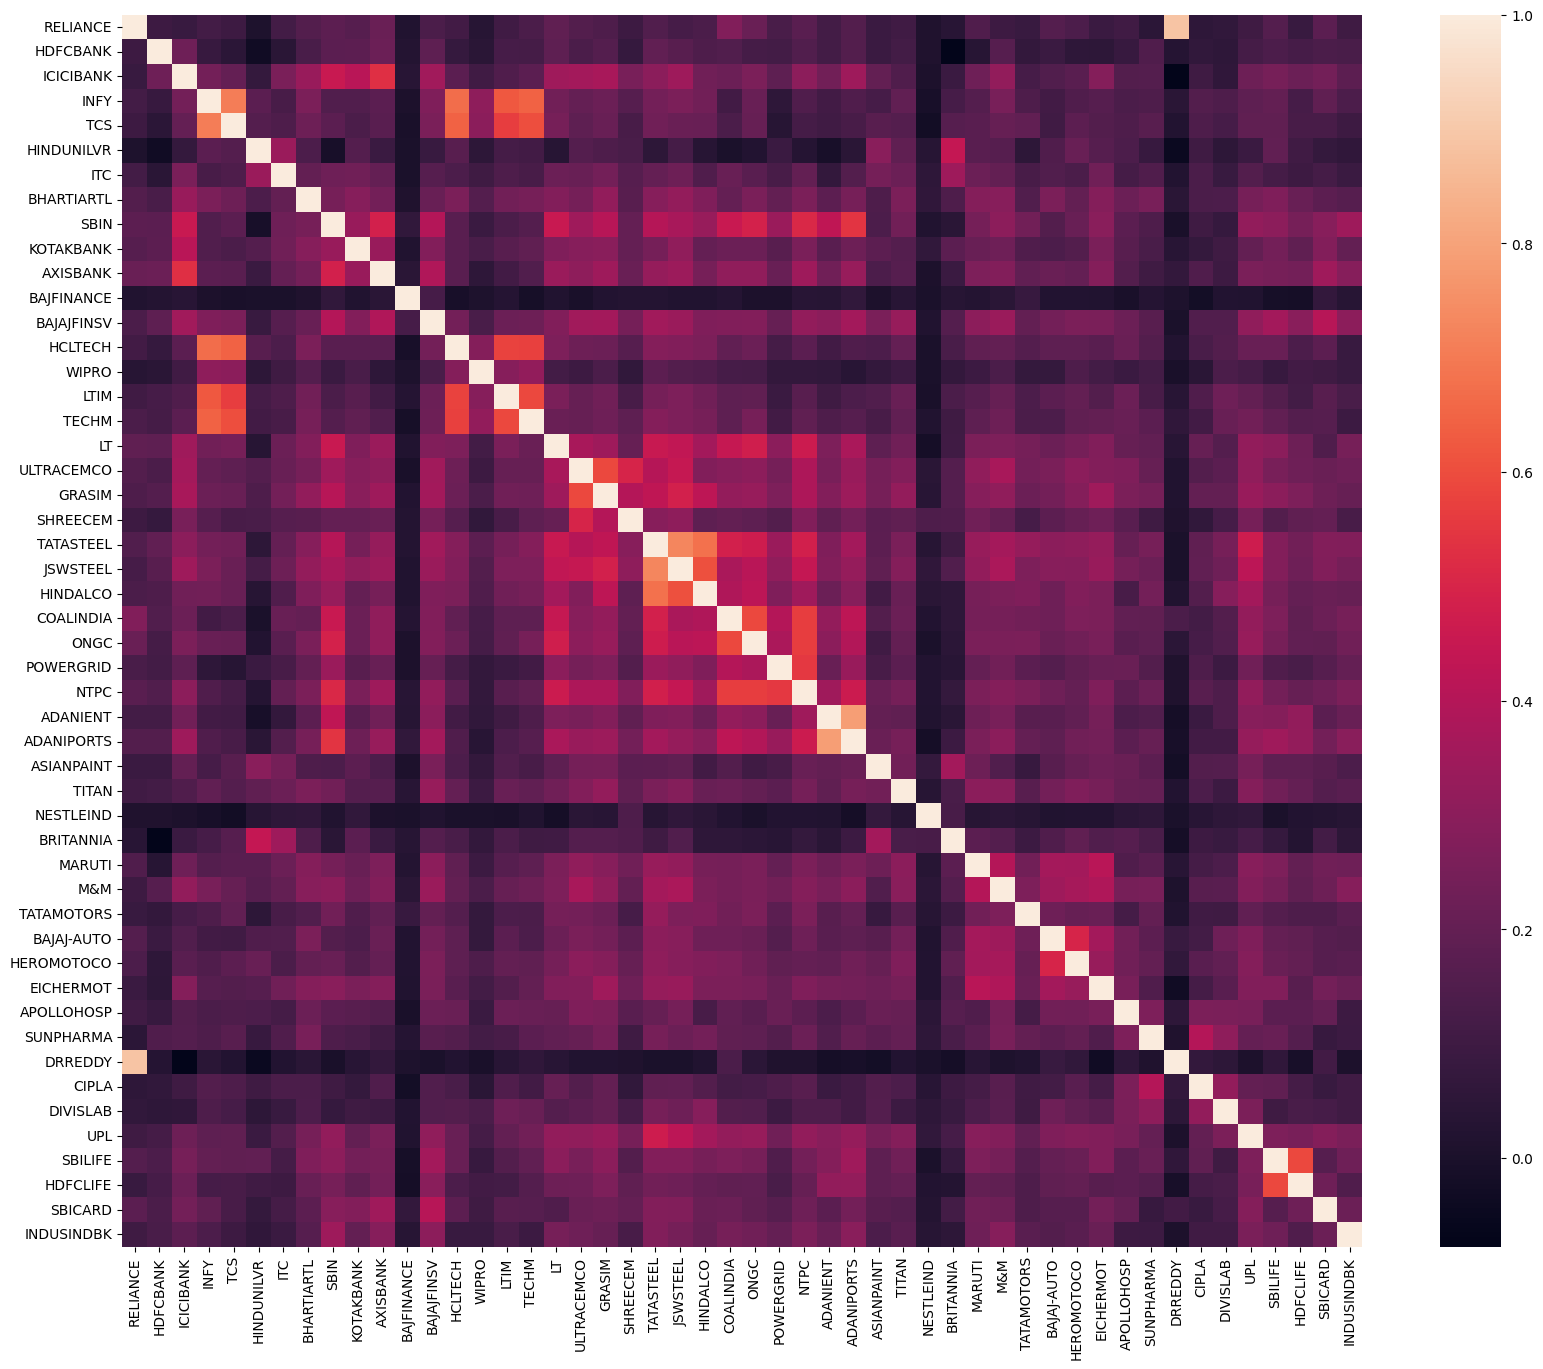

In [26]:
plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix)

In [27]:
corr_matrix.columns

Index(['RELIANCE', 'HDFCBANK', 'ICICIBANK', 'INFY', 'TCS', 'HINDUNILVR', 'ITC',
       'BHARTIARTL', 'SBIN', 'KOTAKBANK', 'AXISBANK', 'BAJFINANCE',
       'BAJAJFINSV', 'HCLTECH', 'WIPRO', 'LTIM', 'TECHM', 'LT', 'ULTRACEMCO',
       'GRASIM', 'SHREECEM', 'TATASTEEL', 'JSWSTEEL', 'HINDALCO', 'COALINDIA',
       'ONGC', 'POWERGRID', 'NTPC', 'ADANIENT', 'ADANIPORTS', 'ASIANPAINT',
       'TITAN', 'NESTLEIND', 'BRITANNIA', 'MARUTI', 'M&M', 'TATAMOTORS',
       'BAJAJ-AUTO', 'HEROMOTOCO', 'EICHERMOT', 'APOLLOHOSP', 'SUNPHARMA',
       'DRREDDY', 'CIPLA', 'DIVISLAB', 'UPL', 'SBILIFE', 'HDFCLIFE', 'SBICARD',
       'INDUSINDBK'],
      dtype='object')

In [29]:
# Create stocks pairs

stocks = merged_df.columns
pairs = list(combinations(stocks, 2))
# pairs

In [31]:
cross_sector_pairs = []
for s1, s2 in pairs:
    if symbol_segment_map[s1] != symbol_segment_map[s2]:
        cross_sector_pairs.append((s1, s2))

# cross_sector_pairs



In [32]:
correlated_pairs = []

for s1, s2 in cross_sector_pairs:
    corr = corr_matrix.loc[s1, s2]
    
    if abs(corr) > 0.3:
        correlated_pairs.append((s1, s2, round(corr, 2)))
    
# correlated_pairs

In [33]:
correlated_pairs_df = pd.DataFrame(correlated_pairs, columns=["Stock1", "Stock2", "Corr_Value"])
correlated_pairs_df

,Stock1,Stock2,Corr_Value
0,RELIANCE,DRREDDY,0.89
1,ICICIBANK,BHARTIARTL,0.33
2,ICICIBANK,LT,0.35
3,ICICIBANK,ULTRACEMCO,0.36
4,ICICIBANK,GRASIM,0.37
...,...,...,...
115,ADANIENT,HDFCLIFE,0.32
116,ADANIPORTS,UPL,0.32
117,ADANIPORTS,SBILIFE,0.35
118,ADANIPORTS,HDFCLIFE,0.32


In [34]:
heatmap_matrix = correlated_pairs_df.pivot(index="Stock1", columns="Stock2", values="Corr_Value")
# heatmap_matrix

C:\Users\pciluser\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: xlabel='Stock2', ylabel='Stock1'>

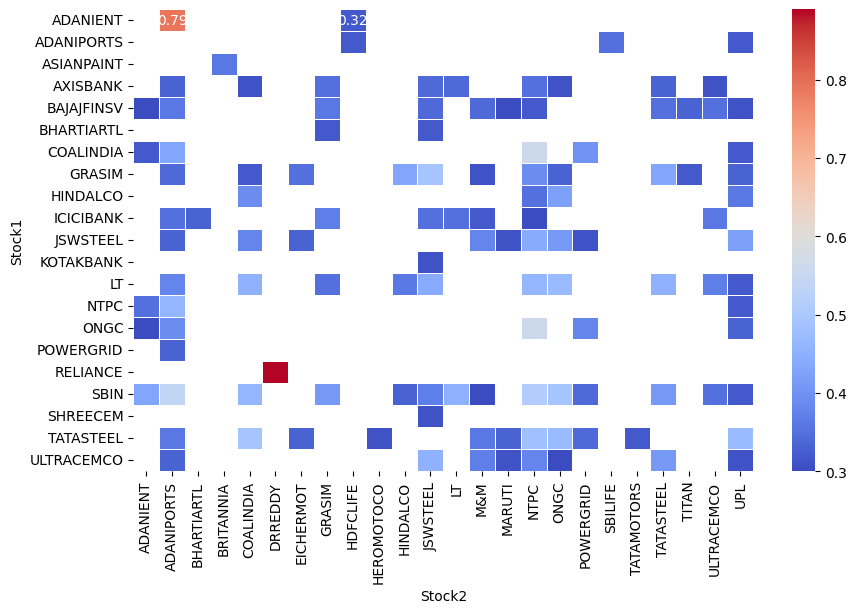

In [35]:
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_matrix,
    cmap="coolwarm",
    annot=True,
    linewidths=0.5
)

In [36]:
cointegrated_pairs = []

for s1, s2, corr in correlated_pairs:
    score, p_value, _ = coint(merged_df[s1], merged_df[s2])
    
    if p_value < 0.05:
        cointegrated_pairs.append((s1, s2, corr, score, p_value))

# cointegrated_pairs

In [37]:
cointegrated_pairs_df = pd.DataFrame(cointegrated_pairs, columns=["Stock1", "Stock2", "Corr_Score", "CoIn_Score", "P_Value"])
cointegrated_pairs_df.sort_values("P_Value")

,Stock1,Stock2,Corr_Score,CoIn_Score,P_Value
9,BAJAJFINSV,TATASTEEL,0.35,-4.431532,0.001583
15,COALINDIA,NTPC,0.56,-4.208353,0.003543
16,ONGC,POWERGRID,0.38,-4.164437,0.004127
19,POWERGRID,ADANIPORTS,0.33,-4.060647,0.005874
4,AXISBANK,LT,0.34,-4.011809,0.006908
0,ICICIBANK,GRASIM,0.37,-3.980538,0.007654
6,AXISBANK,GRASIM,0.35,-3.930962,0.008986
12,GRASIM,HINDALCO,0.43,-3.905179,0.009757
5,AXISBANK,ULTRACEMCO,0.31,-3.757523,0.015428
1,SBIN,GRASIM,0.41,-3.672814,0.019853
